[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jinming99/learn-ml-by-building/blob/main/Lecture%207%20Regularization%20and%20Generalization/07-Overfitting-Regularization.ipynb)

# Lecture 7: From Overfitting to Generalization

A clothing classifier can get every training image right and still struggle with new ones. When should we stop training it, change its data, or change what it is rewarded for?

We will keep returning to [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist): the same ten clothing classes, different ways of learning from limited data. The neural network is our test subject; its architecture is not today's lesson.

In [1]:
# @title Colab Setup
import os, sys, subprocess
from pathlib import Path

if 'google.colab' in sys.modules:
    repo = Path('/content/learn-ml-by-building')
    if not repo.exists():
        subprocess.run(['git', 'clone', '-q', 'https://github.com/jinming99/learn-ml-by-building.git', str(repo)], check=True)
    os.chdir(repo / 'Lecture 7 Regularization and Generalization')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'tensorflow>=2.16,<2.19', 'scikit-learn', 'matplotlib', 'pandas'], check=True)
else:
    print('Running locally: use the Lecture 7 kernel (TensorFlow 2.16+).')

Running locally: use the Lecture 7 kernel (TensorFlow 2.16+).


In [2]:
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, clear_output
import tensorflow as tf
from sklearn.model_selection import train_test_split

try:
    tf.config.threading.set_intra_op_parallelism_threads(2)
    tf.config.threading.set_inter_op_parallelism_threads(1)
except RuntimeError:
    pass  # A running kernel has already initialized TensorFlow.

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 11, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'grid.alpha': .18, 'figure.dpi': 110, 'legend.frameon': False})
COLORS = {'train': '#3A86FF', 'val': '#E76F51', 'teal': '#2A9D8F',
          'purple': '#8338EC', 'ink': '#263238', 'muted': '#8D99AE'}
SEEDS = (42, 43)

def make_model(seed=42, widths=(256, 128, 64), l1=0., l2=0., smoothing=0.):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    penalty = tf.keras.regularizers.L1L2(l1=l1, l2=l2)
    model = tf.keras.Sequential([tf.keras.Input((28, 28)), tf.keras.layers.Flatten()])
    for width in widths:
        model.add(tf.keras.layers.Dense(width, activation='relu', kernel_regularizer=penalty))
    model.add(tf.keras.layers.Dense(10, activation='softmax'))
    model.compile(optimizer=tf.keras.optimizers.Adam(.001),
                  loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=smoothing),
                  metrics=['accuracy'])
    return model

def probabilities(model, x):
    return model.predict(x, batch_size=512, verbose=0)

def scores(p, y):
    return {'Accuracy': np.mean(p.argmax(1) == y),
            'Log loss': -np.log(np.clip(p[np.arange(len(y)), y], 1e-7, 1)).mean(),
            'Brier': np.square(p - np.eye(10)[y]).sum(axis=1).mean()}

def table(rows, formats=None):
    display(pd.DataFrame(rows).style.hide(axis='index').format(formats or {}))

## 1. Watch One Model Learn

We set aside validation images before choosing any training subsets. Validation guides our choices; the official test set stays closed until the final comparison. All subsets below come from the remaining training pool.

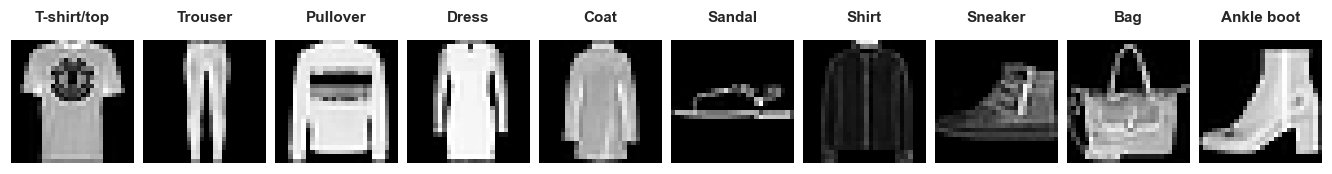

Opening experiment: 300 training images · 5,000 validation images · 10 classes


In [3]:
(images, labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()
images = images.astype('float32') / 255
test_images = test_images.astype('float32') / 255
pool_idx, val_idx = train_test_split(np.arange(len(images)), test_size=5000,
                                    stratify=labels, random_state=42)
train_idx, _ = train_test_split(pool_idx, train_size=1000, stratify=labels[pool_idx], random_state=42)
small_pos, _ = train_test_split(np.arange(1000), train_size=300, stratify=labels[train_idx], random_state=42)
small_idx = train_idx[small_pos]
x_train, y_train = images[train_idx], labels[train_idx]
x_small, y_small = images[small_idx], labels[small_idx]
x_val, y_val = images[val_idx], labels[val_idx]
targets = np.eye(10, dtype='float32')[y_train]
small_targets = np.eye(10, dtype='float32')[y_small]
val_targets = np.eye(10, dtype='float32')[y_val]
assert not np.intersect1d(pool_idx, val_idx).size
assert set(small_idx).issubset(set(train_idx))
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

fig, axes = plt.subplots(1, 10, figsize=(12, 1.8), layout='constrained')
for c, ax in enumerate(axes):
    ax.imshow(x_small[np.flatnonzero(y_small == c)[0]], cmap='gray', vmin=0, vmax=1)
    ax.set_title(class_names[c], fontsize=10)
    ax.axis('off')
plt.show()
print(f'Opening experiment: {len(x_small)} training images · {len(x_val):,} validation images · 10 classes')

Watch the two panels together. If the accuracy stops changing, what else can the loss tell us?

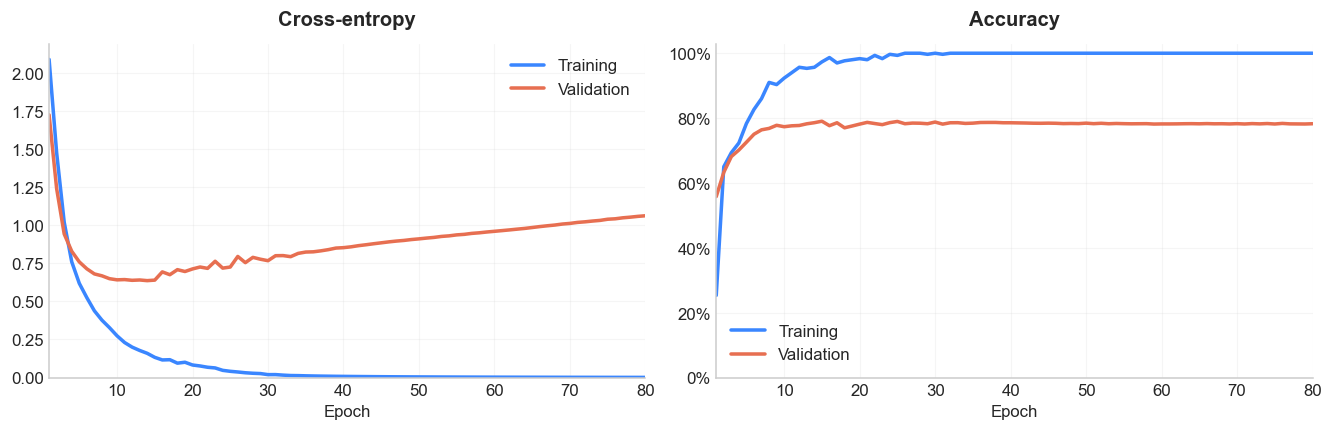

In [4]:
class LiveTrainingMonitor(tf.keras.callbacks.Callback):
    """One live figure; its final frame remains visible when training finishes."""
    def on_train_begin(self, logs=None):
        self.trace = {key: [] for key in ('loss', 'val_loss', 'accuracy', 'val_accuracy')}

    def on_epoch_end(self, epoch, logs=None):
        for key in self.trace:
            self.trace[key].append(logs[key])
        if (epoch + 1) % 5 == 0 or epoch + 1 == self.params['epochs']:
            clear_output(wait=True)
            fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), layout='constrained')
            for ax, metric, title in zip(axes, ['loss', 'accuracy'], ['Cross-entropy', 'Accuracy']):
                steps = np.arange(1, epoch + 2)
                ax.plot(steps, self.trace[metric], color=COLORS['train'], label='Training', lw=2.3)
                ax.plot(steps, self.trace['val_' + metric], color=COLORS['val'], label='Validation', lw=2.3)
                ax.set(title=title, xlabel='Epoch', xlim=(1, self.params['epochs']))
                ax.legend()
            axes[0].set_ylim(bottom=0)
            axes[1].set_ylim(0, 1.03)
            axes[1].yaxis.set_major_formatter(PercentFormatter(1))
            plt.show()

hook_model = make_model()
monitor = LiveTrainingMonitor()
hook_history = hook_model.fit(x_small, small_targets, validation_data=(x_val, val_targets),
                              epochs=80, batch_size=64, callbacks=[monitor], verbose=0).history
hook_last = probabilities(hook_model, x_val)

## 2. Which Checkpoint Would You Keep?

Early stopping uses validation loss to choose when to stop and which weights to keep. **Patience** allows a few disappointing epochs; restoring the best weights is a separate step. We repeat the same run, with the same starting weights and data order, using both.

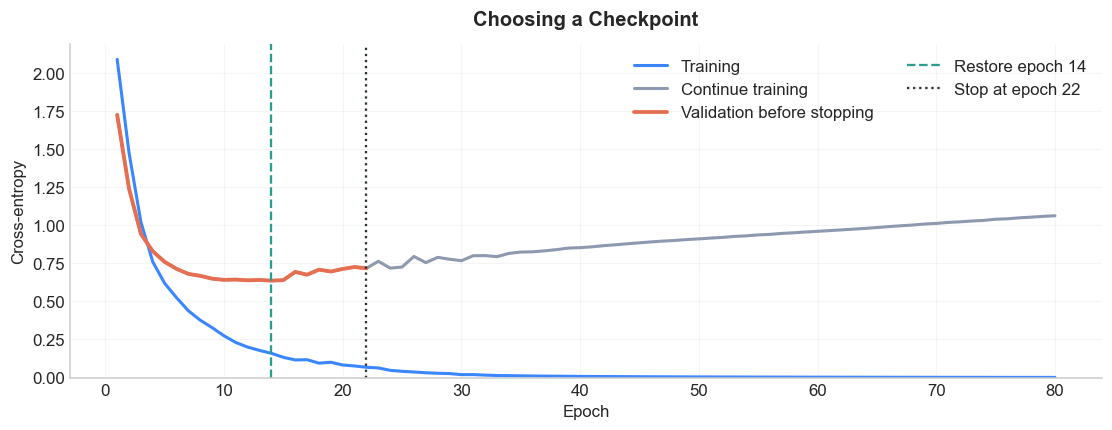

Checkpoint,Accuracy,Log loss,Brier
Last,78.3%,1.059,0.355
Restored,78.6%,0.637,0.308


In [5]:
early_model = make_model()
stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
early_history = early_model.fit(x_small, small_targets, validation_data=(x_val, val_targets),
                                epochs=80, batch_size=64, callbacks=[stop], verbose=0).history
best_epoch = int(np.argmin(early_history['val_loss'])) + 1
stop_epoch = len(early_history['val_loss'])
fig, ax = plt.subplots(figsize=(10, 3.8), layout='constrained')
epochs = np.arange(1, 81)
ax.plot(epochs, hook_history['loss'], color=COLORS['train'], label='Training', lw=2)
ax.plot(epochs, hook_history['val_loss'], color=COLORS['muted'], label='Continue training', lw=2)
ax.plot(np.arange(1, stop_epoch + 1), early_history['val_loss'], color=COLORS['val'], label='Validation before stopping', lw=2.5)
ax.axvline(best_epoch, color=COLORS['teal'], ls='--', label=f'Restore epoch {best_epoch}')
ax.axvline(stop_epoch, color=COLORS['ink'], ls=':', label=f'Stop at epoch {stop_epoch}')
ax.set(title='Choosing a Checkpoint', xlabel='Epoch', ylabel='Cross-entropy', ylim=(0, None))
ax.legend(ncol=2)
plt.show()
early_p = probabilities(early_model, x_val)
table([{'Checkpoint': name, **scores(p, y_val)} for name, p in [('Last', hook_last), ('Restored', early_p)]],
      {'Accuracy': '{:.1%}', 'Log loss': '{:.3f}', 'Brier': '{:.3f}'})

The loss scores the probability assigned to the correct answer, not just whether it wins the vote. Compare the restored and final checkpoints: did continuing to train help the decisions, the probabilities, or neither?

With little data, a single split is noisy. Stratified cross-validation repeats training on several splits, keeping the class proportions similar. The spread describes sensitivity to the split and training randomness; it is not, by itself, proof of overfitting. We will discuss the fold diagram on the whiteboard rather than repeat five learning-curve panels here.

## 3. Change the Model; Change the Data

### Model size

Same 200 training images, same validation images, same optimizer and training budget. Only the width of one hidden layer changes. Each point averages two initializations. Shading spans the two runs’ minimum and maximum errors; it is not a confidence interval.

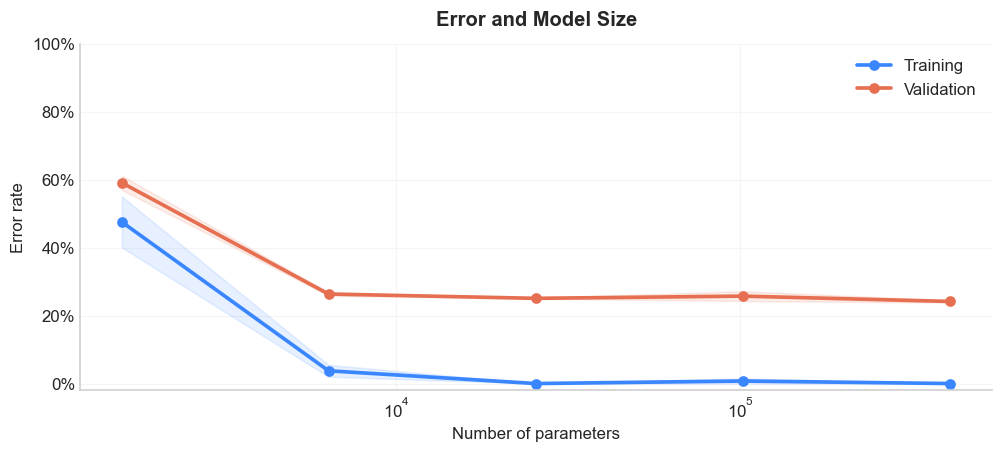

In [6]:
complex_pos, _ = train_test_split(np.arange(1000), train_size=200, stratify=y_train, random_state=42)
complexity_rows = []
for seed in SEEDS:
    for width in [2, 8, 32, 128, 512]:
        model = make_model(seed, widths=(width,))
        model.fit(x_train[complex_pos], targets[complex_pos], epochs=100, batch_size=32, verbose=0)
        complexity_rows.append({'Seed': seed, 'Parameters': model.count_params(),
            'Training': 1 - scores(probabilities(model, x_train[complex_pos]), y_train[complex_pos])['Accuracy'],
            'Validation': 1 - scores(probabilities(model, x_val), y_val)['Accuracy']})
complexity = pd.DataFrame(complexity_rows)
fig, ax = plt.subplots(figsize=(9, 4), layout='constrained')
for label, color in [('Training', COLORS['train']), ('Validation', COLORS['val'])]:
    grouped = complexity.groupby('Parameters')[label]
    mean, low, high = grouped.mean(), grouped.min(), grouped.max()
    ax.plot(mean.index, mean, 'o-', color=color, label=label, lw=2.4)
    ax.fill_between(mean.index, low, high, color=color, alpha=.12)
ax.set(xscale='log', xlabel='Number of parameters', ylabel='Error rate', title='Error and Model Size', ylim=(-.02, 1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend()
plt.show()

**Pause for the poll:** What do you notice? What would you investigate next?

### Training-set size

Now keep the architecture fixed and vary the number of training examples. The subsets are nested; validation images remain the same. Equal epochs mean larger datasets also receive more gradient updates, so this is a practical data-budget comparison, not an equal-compute experiment.

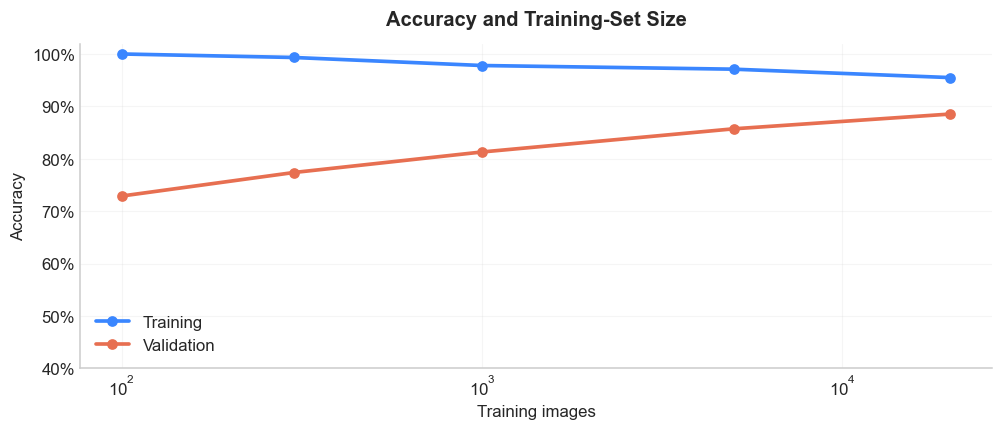

In [7]:
quantity_rows = []
quantity_order = np.random.default_rng(42).permutation(pool_idx)
for size in [100, 300, 1000, 5000, 20000]:
    idx = quantity_order[:size]
    model = make_model(widths=(128,))
    model.fit(images[idx], np.eye(10, dtype='float32')[labels[idx]], epochs=40, batch_size=64, verbose=0)
    quantity_rows.append({'Images': size,
        'Training': scores(probabilities(model, images[idx]), labels[idx])['Accuracy'],
        'Validation': scores(probabilities(model, x_val), y_val)['Accuracy']})
quantity = pd.DataFrame(quantity_rows)
fig, ax = plt.subplots(figsize=(9, 3.8), layout='constrained')
for label, color in [('Training', COLORS['train']), ('Validation', COLORS['val'])]:
    ax.plot(quantity.Images, quantity[label], 'o-', color=color, label=label, lw=2.4)
ax.set(xscale='log', xlabel='Training images', ylabel='Accuracy', title='Accuracy and Training-Set Size', ylim=(.4, 1.02))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend()
plt.show()

### Same budget, different conditions

Imagine photographing the same clothing with two camera setups. One training collection uses only the original dark backgrounds; the other contains a range of brightness and contrast. **These lighting changes are simulated**, not new photographs. Both models receive exactly the same 1,000 source images and labels, once each per epoch, with all ten classes present.

We evaluate both on the same original validation images and the same bright, lower-contrast versions. This tests coverage of a specific, anticipated lighting shift—not arbitrary out-of-distribution generalization.

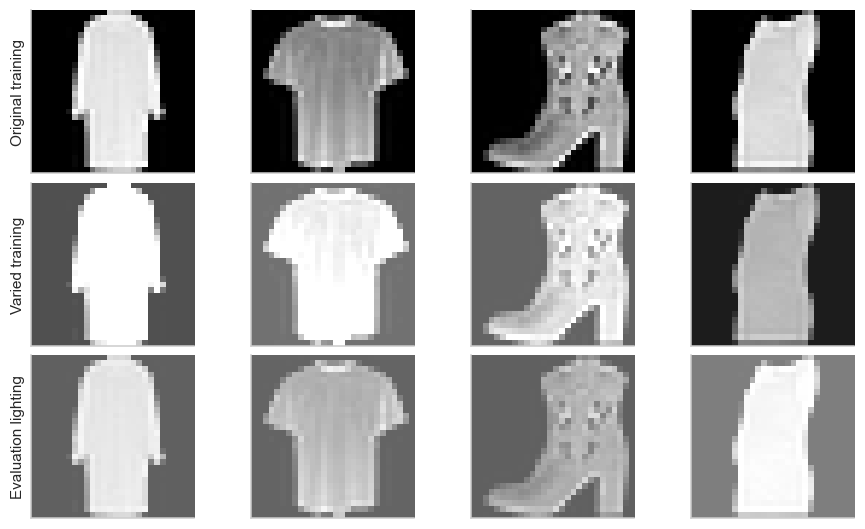

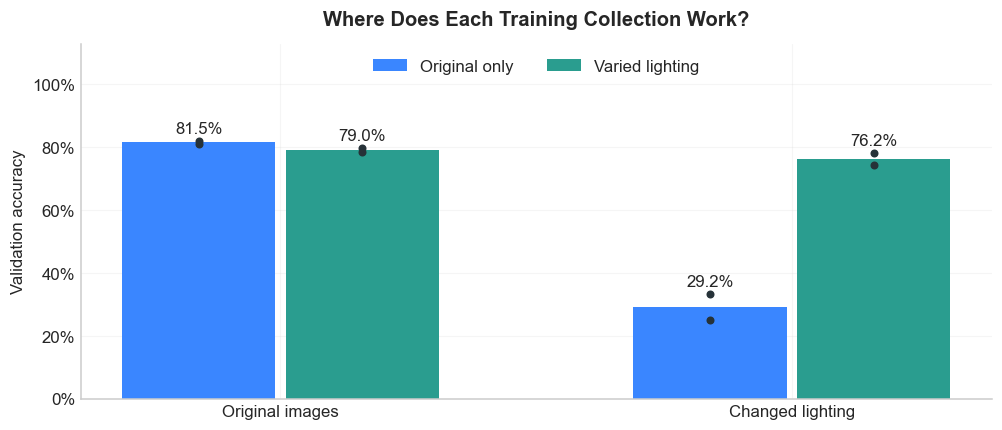

In [8]:
def lighting(x, seed=7, varied=False, shifted=False):
    rng = np.random.default_rng(seed)
    if not (varied or shifted):
        return x.copy()
    brightness = rng.uniform(.25 if shifted else 0, .5, (len(x), 1, 1))
    contrast = rng.uniform(.4, .7 if shifted else 1, (len(x), 1, 1))
    return np.clip(x * contrast + brightness, 0, 1).astype('float32')

varied_train = lighting(x_train, varied=True)
shifted_val = lighting(x_val, seed=99, shifted=True)
fig, axes = plt.subplots(3, 4, figsize=(8, 4.7), layout='constrained')
for row, (batch, label) in enumerate([(x_train, 'Original training'), (varied_train, 'Varied training'),
                                      (lighting(x_train[:4], seed=99, shifted=True), 'Evaluation lighting')]):
    for col in range(4):
        axes[row, col].imshow(batch[col], cmap='gray', vmin=0, vmax=1)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
        axes[row, col].grid(False)
        if col == 0:
            axes[row, col].set_ylabel(label, fontsize=10)
plt.show()

diversity_rows = []
for seed in SEEDS:
    for name, batch in [('Original only', x_train), ('Varied lighting', varied_train)]:
        model = make_model(seed)
        model.fit(batch, targets, epochs=40, batch_size=64, verbose=0)
        diversity_rows.append({'Seed': seed, 'Training collection': name,
            'Original images': scores(probabilities(model, x_val), y_val)['Accuracy'],
            'Changed lighting': scores(probabilities(model, shifted_val), y_val)['Accuracy']})
diversity = pd.DataFrame(diversity_rows)
fig, ax = plt.subplots(figsize=(9, 3.8), layout='constrained')
for j, (name, color) in enumerate([('Original only', COLORS['train']), ('Varied lighting', COLORS['teal'])]):
    values = diversity[diversity['Training collection'] == name]
    means = values[['Original images', 'Changed lighting']].mean()
    bars = ax.bar(np.arange(2) + (j - .5) * .32, means, .3, label=name, color=color)
    for bar, mean, col in zip(bars, means, means.index):
        ax.text(bar.get_x() + bar.get_width()/2, values[col].max() + .025, f'{mean:.1%}', ha='center')
    for k, col in enumerate(means.index):
        ax.scatter(np.full(len(values), k + (j-.5)*.32), values[col], s=18, color=COLORS['ink'], zorder=3)
ax.set(xticks=[0, 1], xticklabels=['Original images', 'Changed lighting'], ylabel='Validation accuracy',
       title='Where Does Each Training Collection Work?', ylim=(0, 1.13))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(loc='upper center', ncol=2)
plt.show()

Compare the two evaluation conditions separately. Varied data should help where it covers the conditions we expect to face; it need not win everywhere. The dots show the two initializations, not confidence intervals.

## 4. Change the Price of Large Weights

Suppose we cannot collect more images. We can change the objective instead:

$$\text{training cross-entropy}+\lambda\,\text{weight penalty},\qquad
L_1:\sum_j |w_j|,\quad L_2:\sum_j w_j^2.$$

Both penalties act on the hidden-layer kernels, not the biases. We use the same 300 training images, initial weights, optimizer, and 80-epoch budget. The validation score below is **ordinary cross-entropy without the penalty**, so the objectives remain comparable. Strengths are classroom settings explored on validation data, not universal defaults.

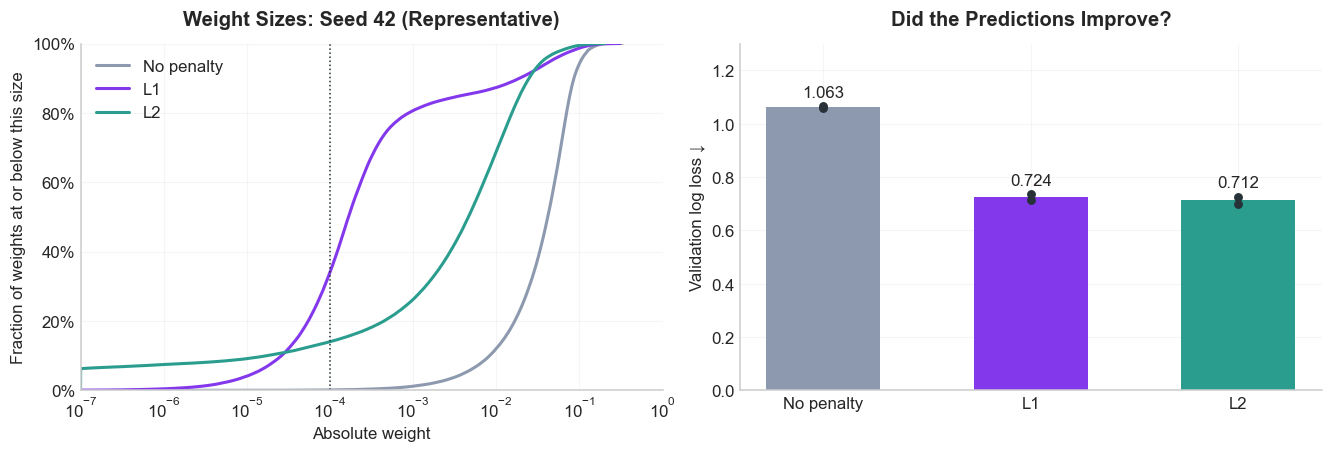

Penalty,Accuracy,Log loss,Near zero
No penalty,78.0%,1.063,0.1%
L1,77.5%,0.724,43.7%
L2,78.0%,0.712,15.4%


In [9]:
penalty_settings = {'No penalty': {}, 'L1': {'l1': .0005}, 'L2': {'l2': .005}}
penalty_rows, penalty_weights, penalty_models = [], {}, {}
for seed in SEEDS:
    for name, settings in penalty_settings.items():
        model = make_model(seed, **settings)
        model.fit(x_small, small_targets, epochs=80, batch_size=64, verbose=0)
        w = np.concatenate([layer.kernel.numpy().ravel() for layer in model.layers[1:-1]])
        penalty_rows.append({'Seed': seed, 'Penalty': name, **scores(probabilities(model, x_val), y_val),
                             'Near zero': np.mean(np.abs(w) < 1e-4)})
        if seed == SEEDS[0]:
            penalty_weights[name], penalty_models[name] = w, model
penalties = pd.DataFrame(penalty_rows)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
penalty_colors = {'No penalty': COLORS['muted'], 'L1': COLORS['purple'], 'L2': COLORS['teal']}
for i, (name, color) in enumerate(penalty_colors.items()):
    absolute = np.sort(np.maximum(np.abs(penalty_weights[name]), 1e-7))
    axes[0].plot(absolute, np.arange(1, len(absolute)+1)/len(absolute), color=color, label=name, lw=2)
    values = penalties.loc[penalties.Penalty == name, 'Log loss']
    axes[1].bar(i, values.mean(), color=color, width=.55)
    axes[1].scatter(np.full(len(values), i), values, color=COLORS['ink'], s=23, zorder=3)
    axes[1].text(i, values.max()+.035, f'{values.mean():.3f}', ha='center')
axes[0].axvline(1e-4, color=COLORS['ink'], ls=':', lw=1)
axes[0].set(xscale='log', xlim=(1e-7, 1), ylim=(0, 1), xlabel='Absolute weight',
            ylabel='Fraction of weights at or below this size', title='Weight Sizes: Seed 42 (Representative)')
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].legend()
axes[1].set(xticks=range(3), xticklabels=list(penalty_colors), ylabel='Validation log loss ↓',
            title='Did the Predictions Improve?', ylim=(0, penalties['Log loss'].max()*1.22))
plt.show()
table(penalties.groupby('Penalty', sort=False)[['Accuracy', 'Log loss', 'Near zero']].mean().reset_index(),
      {'Accuracy': '{:.1%}', 'Log loss': '{:.3f}', 'Near zero': '{:.1%}'})

The vertical dotted line marks **near zero**, $|w|<10^{-4}$, not exact zeros. Ordinary neural-network optimization does not guarantee exact sparsity, and removing one connection does not remove an entire input feature. Compare both accuracy and log loss: getting more answers right and assigning better probabilities are related, but different, goals. Too much regularization can underfit; a smaller training–validation gap is not the objective.

## 5. Change the Targets, Not Just the Weights

### Label smoothing: does less confidence mean better probabilities?

With ten classes and smoothing $\alpha=0.1$, a hard target of 100% becomes **91% for the labeled class and 1% for each other class**:
$$\widetilde y=(1-\alpha)y+\alpha/10.$$
We compare models trained on the same 1,000 images. A reliability diagram asks whether predictions made with, say, 80% confidence are correct about 80% of the time. Lower confidence alone does not answer that question.

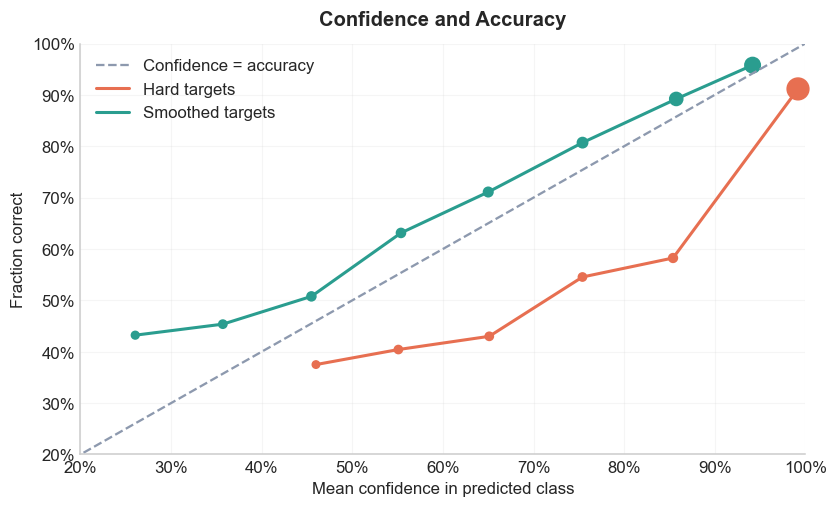

Targets,Accuracy,Log loss,Brier
Hard targets,83.0%,0.772,0.271
Smoothed targets,81.8%,0.661,0.279


In [10]:
calibration_models, calibration_predictions, calibration_rows = {}, {}, []
for name, smoothing in [('Hard targets', 0.), ('Smoothed targets', .1)]:
    model = make_model(smoothing=smoothing)
    model.fit(x_train, targets, epochs=60, batch_size=64, verbose=0)
    p = probabilities(model, x_val)
    calibration_models[name], calibration_predictions[name] = model, p
    calibration_rows.append({'Targets': name, **scores(p, y_val)})

fig, ax = plt.subplots(figsize=(7.5, 4.5), layout='constrained')
ax.plot([0, 1], [0, 1], '--', color=COLORS['muted'], label='Confidence = accuracy')
for (name, p), color in zip(calibration_predictions.items(), [COLORS['val'], COLORS['teal']]):
    confidence, correct = p.max(1), p.argmax(1) == y_val
    points = []
    for lo, hi in zip(np.linspace(0, 1, 11)[:-1], np.linspace(0, 1, 11)[1:]):
        mask = (confidence > lo) & (confidence <= hi)
        if mask.sum() >= 20:
            points.append((confidence[mask].mean(), correct[mask].mean(), mask.sum()))
    points = np.array(points)
    ax.plot(points[:, 0], points[:, 1], color=color, label=name, lw=2)
    ax.scatter(points[:, 0], points[:, 1], s=20+points[:, 2]*.045, color=color, clip_on=False)
ax.set(xlim=(.2, 1), ylim=(.2, 1), xlabel='Mean confidence in predicted class',
       ylabel='Fraction correct', title='Confidence and Accuracy')
ax.xaxis.set_major_formatter(PercentFormatter(1)); ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend()
plt.show()
table(calibration_rows, {'Accuracy': '{:.1%}', 'Log loss': '{:.3f}', 'Brier': '{:.3f}'})

Larger dots contain more examples; bins with fewer than 20 predictions are omitted. Points below the diagonal are overconfident; points above it are underconfident. The diagram is a binned estimate, so use the full-validation log loss and Brier score alongside it rather than declaring a winner from one dot.

### Mixup: blend the answer as well as the image

A blend that is 70% sneaker and 30% bag gets a target of 70% sneaker and 30% bag—not a hard sneaker label.
$$\widetilde x=\lambda x_i+(1-\lambda)x_j,\qquad
\widetilde y=\lambda y_i+(1-\lambda)y_j.$$
[Mixup: Beyond Empirical Risk Minimization](https://arxiv.org/abs/1710.09412) trains on these paired interpolations. Here we test the idea with the same images, starting weights, and update budget as the baseline.

For a cybersecurity application, see our paper [Zero-day Attack Detection in Digital Substations using In-Context Learning](https://ieeexplore.ieee.org/document/10738025/).

First, keep the 1,000-image clean-label comparison: does mixup improve accuracy, probability quality, or both? Then stress-test a different question below: what happens when some training labels are wrong?

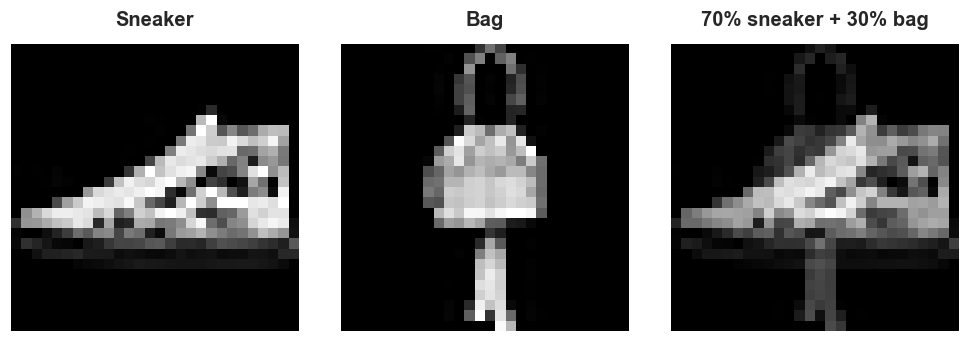

Model,Accuracy,Log loss,Brier
Standard training,83.0%,0.772,0.271
Mixup,81.9%,0.597,0.265


In [11]:
a = np.flatnonzero(y_train == 7)[0]
b = np.flatnonzero(y_train == 8)[0]
blend = .7
fig, axes = plt.subplots(1, 3, figsize=(9, 3), layout='constrained')
for ax, image, title in zip(axes, [x_train[a], x_train[b], blend*x_train[a]+(1-blend)*x_train[b]],
                            ['Sneaker', 'Bag', '70% sneaker + 30% bag']):
    ax.imshow(image, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title); ax.axis('off')
plt.show()

def mixup_batches(x, one_hot, alpha=.2, seed=42, batch_size=64):
    order_rng = np.random.default_rng(seed)
    mix_rng = np.random.default_rng(seed + 10000)
    while True:
        order = order_rng.permutation(len(x))
        for start in range(0, len(x), batch_size):
            idx = order[start:start+batch_size]
            if alpha == 0:
                yield x[idx], one_hot[idx]
                continue
            partner = mix_rng.permutation(idx)
            lam = mix_rng.beta(alpha, alpha, len(idx)).astype('float32')
            mixed_x = lam[:, None, None]*x[idx] + (1-lam[:, None, None])*x[partner]
            mixed_y = lam[:, None]*one_hot[idx] + (1-lam[:, None])*one_hot[partner]
            yield mixed_x, mixed_y

mixed_x, mixed_y = next(mixup_batches(x_train, targets))
assert mixed_x.shape[1:] == (28, 28) and mixed_y.shape[1] == 10
assert np.allclose(mixed_y.sum(1), 1) and np.any((mixed_y > 0) & (mixed_y < 1))
mixup_model = make_model()
mixup_model.fit(mixup_batches(x_train, targets), steps_per_epoch=int(np.ceil(len(x_train)/64)),
                epochs=60, shuffle=False, verbose=0)
mixup_p = probabilities(mixup_model, x_val)

# Keep the original clean-label comparison for the final validation-based choice.
table([{'Model': name, **scores(p, y_val)} for name, p in
       [('Standard training', calibration_predictions['Hard targets']), ('Mixup', mixup_p)]],
      {'Accuracy': '{:.1%}', 'Log loss': '{:.3f}', 'Brier': '{:.3f}'})

### What if one in five training labels is wrong?

Imagine a clothing catalog with some incorrect tags. We **deliberately replace 20% of the training labels with different classes** in a 5,000-image subset. These are simulated annotation errors, not a claim about Fashion-MNIST. Validation images and labels stay unchanged.

Within each pair, both methods get the same images, wrong labels, starting weights, batch order, optimizer, and 80-epoch budget. Only mixup changes. We repeat with three seeds, changing the initialization, batch order, and which labels are wrong. Here $\alpha=4$ favors substantial blends; this is a validation-explored stress-test setting, not a universal default.

Watch the connection between **learning the wrong training answers** and **recognizing clean, unseen images**. More agreement with the deliberately wrong labels is not progress.

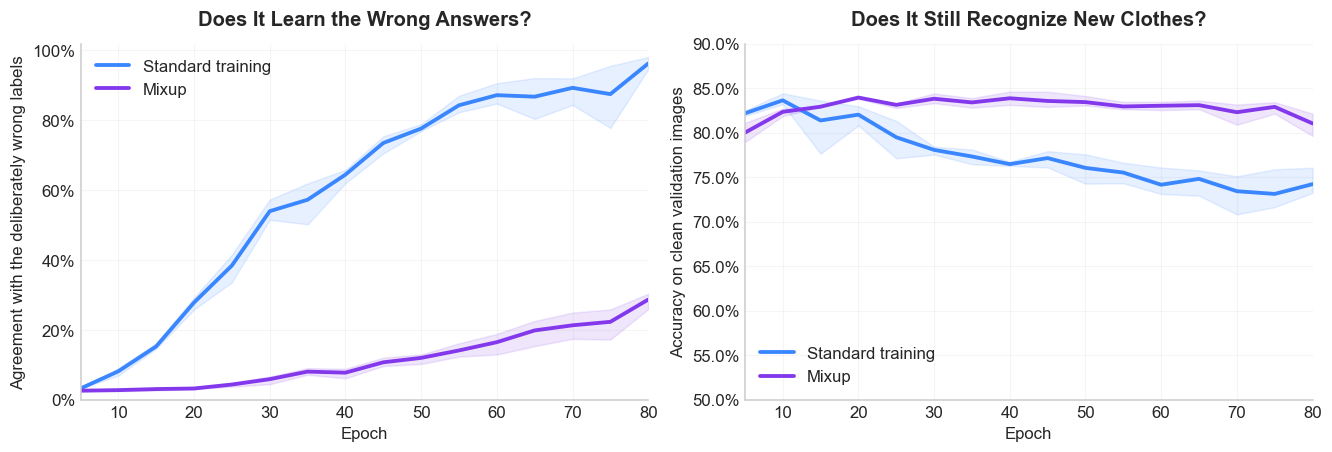

Checkpoint,Method,Accuracy,Log loss
Epoch 80,Standard training,74.2%,1.368
Epoch 80,Mixup,81.0%,0.722
Best logged validation loss,Mixup,83.7%,0.634
Best logged validation loss,Standard training,83.4%,0.630


In [12]:
# One in five training labels is wrong; validation labels are never changed.
stress_idx, _ = train_test_split(pool_idx, train_size=5000,
                                stratify=labels[pool_idx], random_state=42)
stress_x, stress_y = images[stress_idx], labels[stress_idx]
stress_rows = []
for seed in (42, 43, 44):
    rng = np.random.default_rng(seed + 5000)
    wrong = rng.choice(len(stress_y), 1000, replace=False)
    observed = stress_y.copy()
    observed[wrong] = (observed[wrong] + rng.integers(1, 10, len(wrong))) % 10
    noisy_targets = np.eye(10, dtype='float32')[observed]
    for method, alpha in [('Standard training', 0.), ('Mixup', 4.)]:
        stress_model = make_model(seed)

        def record(epoch, logs):
            if (epoch + 1) % 5 == 0:
                p = probabilities(stress_model, x_val)
                wrong_predictions = probabilities(stress_model, stress_x[wrong]).argmax(1)
                stress_rows.append({'Seed': seed, 'Method': method, 'Epoch': epoch + 1,
                    **scores(p, y_val), 'Wrong-label agreement':
                    np.mean(wrong_predictions == observed[wrong])})

        stress_model.fit(mixup_batches(stress_x, noisy_targets, alpha=alpha, seed=seed),
            epochs=80, steps_per_epoch=int(np.ceil(len(stress_x)/64)), shuffle=False,
            callbacks=[tf.keras.callbacks.LambdaCallback(on_epoch_end=record)], verbose=0)

stress = pd.DataFrame(stress_rows)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
for method, color in [('Standard training', COLORS['train']), ('Mixup', COLORS['purple'])]:
    runs = stress[stress.Method == method]
    for ax, metric in zip(axes, ['Wrong-label agreement', 'Accuracy']):
        grouped = runs.groupby('Epoch')[metric]
        ax.plot(grouped.mean().index, grouped.mean(), color=color, lw=2.5, label=method)
        ax.fill_between(grouped.mean().index, grouped.min(), grouped.max(), color=color, alpha=.12)
axes[0].set(title='Does It Learn the Wrong Answers?',
            ylabel='Agreement with the deliberately wrong labels', ylim=(0, 1.02))
axes[1].set(title='Does It Still Recognize New Clothes?',
            ylabel='Accuracy on clean validation images', ylim=(.5, .9))
for ax in axes:
    ax.set(xlabel='Epoch', xlim=(5, 80))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.legend()
plt.show()

# Include a checkpoint-selection comparison, not only an overtrained baseline.
last = stress[stress.Epoch == 80].assign(Checkpoint='Epoch 80')
best = stress.loc[stress.groupby(['Seed', 'Method'])['Log loss'].idxmin()]
best = best.assign(Checkpoint='Best logged validation loss')
stress_summary = pd.concat([last, best]).groupby(['Checkpoint', 'Method'], sort=False)[
    ['Accuracy', 'Log loss']].mean().reset_index()
table(stress_summary, {'Accuracy': '{:.1%}', 'Log loss': '{:.3f}'})

The curves show the mean and full range across three runs, not confidence intervals. Compare the final checkpoints, then check the table's validation-selected checkpoints too. The best logged checkpoint is selected retrospectively from measurements every five epochs after all 80 epochs have run; it is not an early-stopping policy. Mixup can resist memorizing wrong labels; early checkpoint selection is also a strong defense. The best logged checkpoints are selected and scored on the same validation set, so these are exploratory comparisons, not independent test estimates.

This is a controlled noisy-label experiment, not a guarantee that mixup improves clean-data accuracy or handles arbitrary distribution shifts. Keep it separate from the clean-label comparison below.

## 6. One Final Check

For the original **1,000-image, clean-label experiment**, select among hard targets, smoothed targets, and mixup by **validation log loss**. The noisy-label models above are not candidates: they used a different training set and targets. Freeze the choice, then evaluate on the official test set. Report the baseline too. This is a classroom study on a familiar benchmark, not an untouched research benchmark.

In [13]:
final_candidates = {**calibration_models, 'Mixup': mixup_model}
candidate_predictions = {**calibration_predictions, 'Mixup': mixup_p}
selected_name = min(candidate_predictions, key=lambda name: scores(candidate_predictions[name], y_val)['Log loss'])
final_rows = []
for name in dict.fromkeys(['Hard targets', selected_name]):
    p = probabilities(final_candidates[name], test_images)
    final_rows.append({'Model': name, **scores(p, test_labels)})
print(f'Chosen using validation only: {selected_name}')
table(final_rows, {'Accuracy': '{:.1%}', 'Log loss': '{:.3f}', 'Brier': '{:.3f}'})

Chosen using validation only: Mixup


Model,Accuracy,Log loss,Brier
Hard targets,80.5%,0.927,0.318
Mixup,79.6%,0.672,0.299


## Wrap-up

Fitting the training data is only the beginning. Validation tells us when further training stops helping and lets us compare changes to the data, the weights, and the targets. More representative examples can help under the conditions we expect to face; penalties, early stopping, label smoothing, and mixup change what the model is encouraged to learn. None is an automatic upgrade. Judge the resulting predictions on the same held-out examples, distinguish accuracy from probability quality, and keep the final test separate from the choices that produced the model.